# Set up

In [ ]:
#load packages
import pandas as pd
import numpy as np
import mne
import matplotlib.pyplot as plt
from nilearn import image
from scipy import stats
from scipy.stats import pearsonr, ttest_ind
import pingouin as pg
import seaborn as sns
from nilearn import surface

from utils import get_color, annotate_regression_corr_bayes

In [ ]:
#set directories
project_dir = 'os.chdir('..')'
data_dir = f'{project_dir}data/'
fs_dir = f'{data_dir}freesurfer/'
fig_dir=f'{project_dir}figures/'

# specify variables
groups = ['dys','typ']
ROIs=['VWFA1','VWFA2']
hemi='LH'

# set color palette
# Define your color palettes for each ROI
dysGroup_palette_VWFA1 = {'dys': '#BBF451', 'typ': '#05DF72'}
dysGroup_palette_VWFA2 = {'dys': '#53EAFD', 'typ': '#0097b2'}

# Calculate Group Distances

In [11]:
# flag to save data
save_csv=False

#load invidiual center coordinate data
coords_df = pd.read_csv(f'{data_dir}DFs/coords.csv').query('hemi=="LH"')
# create signle column containing array of coordinates
coords_df['coordinates'] = coords_df[['X', 'Y', 'Z']].apply(np.array, axis=1)


# load fsavera surface mesh and coordinates
mesh = surface.load_surf_mesh(f'{fs_dir}fsaverage/surf/lh.inflated')
mesh_coords = mesh.coordinates

# Create a list to store all the distance calcualtions
all_data = []

# loop through groups and rois
for group in groups:
    for roi in ROIs:
        
        # load the group center coordinates
        group_center = mne.read_label(f'{data_dir}ROI_centers/group_centers/{group}_{roi}_medoid-{hemi.lower()}.label')
        group_center_coords = mesh_coords[group_center.vertices[0]]
        
        #subset relevant data
        my_data = coords_df.query('dys_group==@group and roi==@roi')

       # calculate distance and assign value to new dist_2_groupCenter column
        my_data = my_data.assign(
            dist_2_groupCenter=my_data['coordinates'].apply(
                lambda coord: np.linalg.norm(coord - group_center_coords)
            )
        )
        
        # append to list
        all_data.append(my_data)

# Concatenate all dataframes together
distances_df = pd.concat(all_data, ignore_index=True)

if save_csv:
    distances_df.to_csv(f'{data_dir}DFs/group_distances.csv',index=False)

# Plot and Analyze

VWFA1
dys: 8.977, 5.392
typ: 8.600, 5.921
t(59.00)=0.251 (p=0.8026; CI=(-2.63, 3.39))
VWFA2
dys: 12.298, 6.984
typ: 12.506, 6.716
t(54.00)=-0.109 (p=0.9139; CI=(-4.05, 3.64))


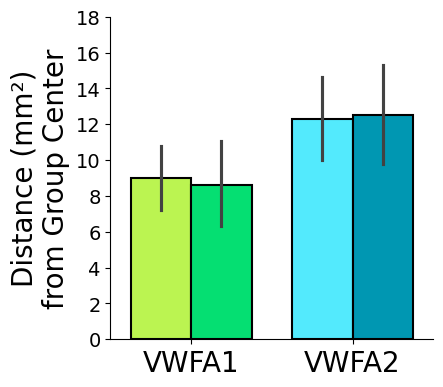

In [ ]:
# Set to True if you want to save the figure
save_fig = False

# Define color palettes for each ROI
vwfa1_palette = {'dys': '#BBF451', 'typ': '#05DF72'}
vwfa2_palette = {'dys': '#53EAFD', 'typ':'#0097b2'}

# Create a combined color mapping column
distances_df['color'] = distances_df.apply(get_color, axis=1, args=(vwfa1_palette, vwfa2_palette))

# Create palette dictionary for seaborn
palette_dict = {}
for roi in ['VWFA1', 'VWFA2']:
    for group in ['dys', 'typ']:
        subset = distances_df[(distances_df['roi'] == roi) & (distances_df['dys_group'] == group)]
        if len(subset) > 0:
            palette_dict[(roi, group)] = subset['color'].iloc[0]

# ROI labels and legend labels
legend_labels = ['Dyslexic', 'Typical']

# Calculate p-values for significance using t-tests
roi_labels = distances_df['roi'].unique()
p_values = []
t_values=[]
DOFs=[]
CIs=[]
avg_sizes=[]
for roi in roi_labels:
    # Get sizes for each ROI and group
    roi_df = distances_df.query('roi==@roi')
    dys_dist = roi_df.query('dys_group=="dys"')
    typ_dist = roi_df.query('dys_group=="typ"')

    # run test
    results = ttest_ind(dys_dist['dist_2_groupCenter'], typ_dist['dist_2_groupCenter'], equal_var=False)

    # grab results
    t = results.statistic
    p = results.pvalue
    DOF = results.df
    CI = results.confidence_interval()
    
    #append results
    t_values.append(t)
    p_values.append(p)
    DOFs.append(DOF)
    CIs.append(CI)

    #Calculate bayes factor
    bf10 = pg.bayesfactor_ttest(
        t=t,
        nx=len(dys_dist['dist_2_groupCenter']),
        ny=len(typ_dist['dist_2_groupCenter']),
        paired=False,
        alternative='two-sided',
        r=0.707
    )
    bf01 = 1 / bf10
    
    #print results
    print(roi)
    print(f'dys: {np.mean(dys_dist["dist_2_groupCenter"]):.3f}, {np.std(dys_dist["dist_2_groupCenter"]):.3f}')
    print(f'typ: {np.mean(typ_dist["dist_2_groupCenter"]):.3f}, {np.std(typ_dist["dist_2_groupCenter"]):.3f}')
    print(f't({DOF:.2f})={t:.3f} (p={p:.4f}; CI=({CI.low:.2f}, {CI.high:.2f}))')
    print(f'bf01 = {bf01:.3f}')

# Plot the data
g = sns.catplot(x='roi', y='dist_2_groupCenter', hue='dys_group', hue_order=['dys', 'typ'],
                data=distances_df, kind='bar',
                height=4, aspect=1, width=0.75, legend=False)
g.set_axis_labels("", "Distance (mm\u00b2)\nfrom Group Center", size=20)
g.set_xticklabels(size=20)
g.set_yticklabels(size=14)

# Manually color the bars based on ROI
ax = g.axes.flat[0]
for i, bar in enumerate(ax.patches):
    # Determine which ROI and group this bar belongs to
    roi_idx = i % 2  # 0 for VWFA1, 1 for VWFA2
    group_idx = i // 2  # 0 for dys, 1 for typ
    
    roi = roi_labels[roi_idx]
    group = ['dys', 'typ'][group_idx]
    
    # Set the color
    if roi == 'VWFA1':
        bar.set_facecolor(vwfa1_palette[group])
    elif roi == 'VWFA2':
        bar.set_facecolor(vwfa2_palette[group])
    
    # Add border
    bar.set_edgecolor('black')  
    bar.set_linewidth(1.5)

# Add significance indicators
for i, p in enumerate(p_values):
    significance = ''
    if pd.notna(p):
        if p < 0.001:
            significance = '***'
        elif p < 0.01:
            significance = '**'
        elif p < 0.05:
            significance = '*'
        elif p >= 0.05:
            significance = ''
    if significance:
        # Position the text above the highest box for the given ROI
        y_max = 175
        if np.isfinite(y_max):  
            ax = g.axes.flat[0]
            ax.text(i, y_max + 0.1, significance, ha='center', va='bottom', fontsize=20, color='black')

# Save the figure
if save_fig:
    plt.savefig(f'{fig_dir}distnaces_bar.png', bbox_inches="tight", dpi=400)

# Calculate All Sub Distances

In [22]:
# flag to save data
save_csv=False

#define variables
assessments = ['wj_brs']
my_var = 'dist_2_center'

#load invidiual center coordinate data
coords_df = pd.read_csv(f'{data_dir}DFs/coords.csv').query('hemi=="LH"')
# create signle column containing array of coordinates
coords_df['coordinates'] = coords_df[['X', 'Y', 'Z']].apply(np.array, axis=1)


# load fsaverage surface mesh coordinates
mesh_coords = mesh.coordinates

# Create a list to store all the distance calcualtions
all_data = []

# loop through groups and rois
for roi in ROIs:

    # load the group center coordinates
    group_center = mne.read_label(f'{data_dir}ROI_centers/allSubs_{roi}_medoid-lh.label')
    group_center_coords = mesh_coords[group_center.vertices[0]]

    #subset relevant data
    my_data = coords_df.query('roi==@roi')

   # calculate distance and assign value to new dist_2_groupCenter column
    my_data = my_data.assign(
        dist_2_center=my_data['coordinates'].apply(
            lambda coord: np.linalg.norm(coord - group_center_coords)
        )
    )

    # append to list
    all_data.append(my_data)

# Concatenate all dataframes together
distances_df = pd.concat(all_data, ignore_index=True)

# Pivot long and create a new column for the assessment
data_long = pd.melt(distances_df, id_vars=['sub', 'roi', 'dys_group','hemi',my_var], value_vars=assessments, 
                    var_name='assessment', value_name='score')

if save_csv:
    data_long.to_csv(f'{data_dir}DFs/distances.csv',index=False)

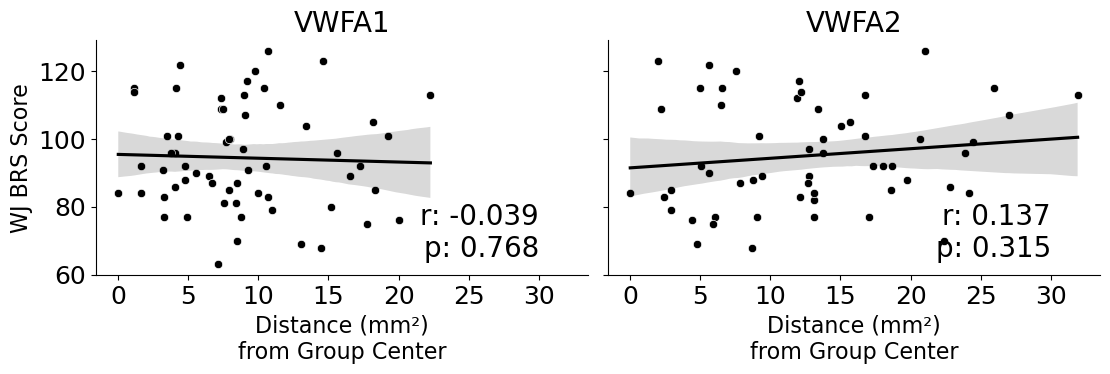

In [ ]:
save_fig = False

# Define assessment titles
titles = {
    'wj_brs': 'WJ BRS'
}

dysGroup_palette = {
    'dys': '#8E44AD',
    'typ': '#BB8FCE'}

#define variables
assessments = ['wj_brs']
rois = ['VWFA1','VWFA2']

# Create a FacetGrid
g = sns.FacetGrid(data_long, row='assessment', col='roi', 
                  height=4, 
                  aspect=1.4, 
                  palette=list(dysGroup_palette.values()))

# Map the scatterplot and regplot onto the FacetGrid
g.map(sns.scatterplot, my_var, 'score', color='black')
g.map(sns.regplot, my_var, 'score', scatter=False, color='black')

# Apply the annotation function to each subplot
g.map_dataframe(annotate_regression_corr_bayes,x_param=my_var,y_param='score')

# Set uniform x and y-axis labels
g.set_axis_labels('Distance (mm\u00b2)\nfrom Group Center', 'WJ BRS Score', size=16)
g.set(xticks=np.arange(0,31,5))

# Iterate through the axes and set the tick label font size
for ax in g.axes.flat:
    ax.tick_params(axis='both', labelsize=18)

# Set titles and labels for each subplot
for i, roi in enumerate(rois):
    for j, assessment in enumerate(assessments):
        ax = g.axes[j, i]
        ax.set_title(f'{roi}', size=20)

# Adjust layout to ensure labels are visible
plt.tight_layout(rect=[0, 0, 1, 0.96])

if save_fig:
    g.savefig(f'{fig_dir}distanceXscores.png', bbox_inches="tight", dpi=400)

plt.show()
